In [32]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import networkx as nx
from monte_carlo_sdp import *
from same_decision_probability_calculation import *


def run_mcmc_diagnostics_v2(bn, target, target_value, patient, threshold,
                             n_iterations=100000, n_chains=4,
                             use_lw_seed=True):
    """
    Runs MCMC diagnostics for the NumPy-vectorised fast_mcmc_sdp_estimation.

    Uses the same integer-indexed inner loop as the production MCMC,
    so the diagnostics reflect the actual chain behaviour.

    Produces three plots:
      1. Trace plot  — running decision fraction per chain (burn-in)
      2. ACF         — autocorrelation of decision indicator (thinning)
      3. R-hat       — Gelman-Rubin convergence over time

    Parameters
    ----------
    use_lw_seed : bool
        If True, seeds via fast ancestral sampling (same as production).
        If False, uses pure random init (for comparison).
    """
    hidden_vars       = [n for n in bn.nodes() if n not in patient and n != target]
    target_states_list = bn.get_cpds(target).state_names[target]
    n_target_states   = len(target_states_list)
    target_state_idx  = list(range(n_target_states))

    # ── Build integer-indexed CPD tables (same as production MCMC) ───────────
    all_nodes   = list(bn.nodes())
    state_index = {}
    for n in all_nodes:
        cpd = bn.get_cpds(n)
        state_index[n] = {s: i for i, s in enumerate(cpd.state_names[n])}

    cpd_array = {}
    cpd_vars  = {}
    for n in all_nodes:
        cpd = bn.get_cpds(n)
        arr = np.asarray(cpd.values, dtype=float)
        arr[arr == 0.0] = 1e-10
        arr = arr / arr.sum(axis=0, keepdims=True)
        cpd_array[n] = arr
        cpd_vars[n]  = list(cpd.variables)

    children_cache = {v: list(bn.get_children(v)) for v in hidden_vars}
    affected_cache = {v: [v] + children_cache[v] for v in hidden_vars}

    inv_state = {v: {i: s for s, i in state_index[v].items()} for v in bn.nodes()}

    # Patient integer lookup
    patient_idx = {v: state_index[v][val] for v, val in patient.items()}

    # ── Helpers ───────────────────────────────────────────────────────────────
    def full_log_joint(state_idx_dict, t_idx):
        lp = 0.0
        for node in all_nodes:
            idx = tuple(
                t_idx if v == target else state_idx_dict[v]
                for v in cpd_vars[node]
            )
            p = cpd_array[node][idx]
            if p == 0.0:
                return float('-inf')
            lp += math.log(p)
        return lp

    def log_sum(values):
        finite = [v for v in values if v != float('-inf')]
        if not finite:
            return float('-inf')
        m = max(finite)
        return m + math.log(sum(math.exp(v - m) for v in finite))

    def get_seed(use_lw):
        idx = dict(patient_idx)
        if use_lw:
            try:
                topo_order = list(nx.topological_sort(bn))
                sample = dict(patient)
                for node in topo_order:
                    if node in sample or node == target or node not in hidden_vars:
                        continue
                    cpd     = bn.get_cpds(node)
                    parents = cpd.variables[1:]
                    if not parents:
                        probs = cpd_array[node].flatten()
                    else:
                        parent_idx_tuple = tuple(
                            state_index[p][sample[p]] if p in sample else 0
                            for p in parents
                        )
                        probs = cpd_array[node][(slice(None),) + parent_idx_tuple]
                    probs = np.array(probs, dtype=float)
                    probs = np.maximum(probs, 0)
                    total = probs.sum()
                    probs = probs / total if total > 0 else np.ones(len(probs)) / len(probs)
                    sampled = np.random.choice(len(probs), p=probs)
                    sample[node]   = inv_state[node][sampled]
                    idx[node]      = sampled
            except Exception as e:
                print(f"    [SEED] Ancestral seed failed ({e}) — random fallback")
                for v in hidden_vars:
                    idx[v] = random.randrange(cpd_array[v].shape[0])
        else:
            for v in hidden_vars:
                idx[v] = random.randrange(cpd_array[v].shape[0])
        return idx

    def run_chain(chain_idx):
        print(f"  Chain {chain_idx + 1}/{n_chains}...")
        current_idx   = get_seed(use_lw_seed)
        current_lj    = [full_log_joint(current_idx, t) for t in target_state_idx]
        current_log_p = log_sum(current_lj)
        print("CURRENT LOG P ")
        print(current_log_p)

        decisions = []

        for i in range(n_iterations):
            var = random.choice(hidden_vars)
            cur_val    = current_idx[var]
            cardinality = cpd_array[var].shape[0]
            if cardinality < 2:
                pass
            else:
                new_val = random.randrange(cardinality - 1)
                if new_val >= cur_val:
                    new_val += 1

                proposed_lj = [0.0] * n_target_states
                recompute   = False

                for t_idx in target_state_idx:
                    if current_lj[t_idx] == float('-inf'):
                        recompute = True
                        break
                    delta  = 0.0
                    failed = False
                    for node in affected_cache[var]:
                        order = cpd_vars[node]
                        p_old_args = tuple(
                            t_idx if v == target else current_idx[v]
                            for v in order
                        )
                        p_new_args = tuple(
                            t_idx if v == target
                            else (new_val if v == var else current_idx[v])
                            for v in order
                        )
                        p_old = cpd_array[node][p_old_args]
                        p_new = cpd_array[node][p_new_args]
                        if p_new == 0.0:
                            failed = True; break
                        if p_old == 0.0:
                            recompute = True; break
                        delta += math.log(p_new) - math.log(p_old)
                    if recompute:
                        break
                    if failed:
                        proposed_lj[t_idx] = float('-inf')
                        continue
                    proposed_lj[t_idx] = current_lj[t_idx] + delta

                if recompute:
                    tmp = dict(current_idx)
                    tmp[var]     = new_val
                    proposed_lj  = [full_log_joint(tmp, t) for t in target_state_idx]

                proposed_log_p = log_sum(proposed_lj)
                log_alpha      = proposed_log_p - current_log_p

                if log_alpha >= 0 or (
                    proposed_log_p != float('-inf')
                    and math.log(random.random()) < log_alpha
                ):
                    current_idx[var] = new_val
                    current_lj       = proposed_lj
                    current_log_p    = proposed_log_p

            # Record decision at every iteration
            sample_h = {v: inv_state[v][current_idx[v]] for v in hidden_vars}
            full_ev  = {**patient, **sample_h}
            p_target = get_exact_target_posterior_O1(bn, target, target_value, full_ev)
            decisions.append(1 if p_target >= threshold else 0)

        return decisions

    # ── Run all chains ────────────────────────────────────────────────────────
    all_chains = np.array([run_chain(c) for c in range(n_chains)], dtype=float)

    # ── Plot 1: Trace plot (running mean) ─────────────────────────────────────
    running_means = np.cumsum(all_chains, axis=1) / np.arange(1, n_iterations + 1)

    fig, axes = plt.subplots(3, 1, figsize=(13, 13))
    seed_label = "ancestral seed" if use_lw_seed else "random seed"

    ax = axes[0]
    for c in range(n_chains):
        ax.plot(running_means[c], alpha=0.7, label=f'Chain {c+1}')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Running mean of decision indicator')
    ax.set_title(f'Trace plot — {bn.name} ({seed_label})\n'
                 f'burn-in = iteration where all chains stabilise')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # ── Plot 2: ACF ───────────────────────────────────────────────────────────
    MAX_LAG     = 1000
    signal      = all_chains[0] - all_chains[0].mean()
    acf_raw     = np.correlate(signal, signal, mode='full')
    acf_raw     = acf_raw[len(acf_raw) // 2:]
    acf_vals    = acf_raw / acf_raw[0]
    significance = 1.96 / math.sqrt(n_iterations)

    ax = axes[1]
    ax.bar(np.arange(MAX_LAG), acf_vals[:MAX_LAG], color='steelblue', alpha=0.7)
    ax.axhline( significance, color='red', ls='--', label='95% significance band')
    ax.axhline(-significance, color='red', ls='--')
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autocorrelation')
    ax.set_title(f'ACF — chain 1\n'
                 f'thinning = smallest lag where ACF enters the red band')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # ── Plot 3: Gelman-Rubin R-hat ────────────────────────────────────────────
    rhat_values  = []
    check_points = list(range(100, n_iterations, max(100, n_iterations // 500)))

    for t in check_points:
        chains_t     = all_chains[:, :t]
        n, m         = chains_t.shape[1], n_chains
        chain_means  = chains_t.mean(axis=1)
        grand_mean   = chain_means.mean()
        B            = n / (m - 1) * np.sum((chain_means - grand_mean) ** 2)
        W            = np.mean(np.var(chains_t, axis=1, ddof=1))
        var_hat      = (1 - 1/n) * W + B / n
        rhat         = math.sqrt(var_hat / W) if W > 0 else float('nan')
        rhat_values.append(rhat)

    ax = axes[2]
    ax.plot(check_points, rhat_values, color='darkgreen', lw=1.5)
    ax.axhline(1.1, color='red',  ls='--', label='R-hat=1.1 (warning)')
    ax.axhline(1.0, color='gray', ls=':')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Gelman-Rubin R-hat')
    ax.set_title('R-hat convergence\n(should drop and stay below 1.1)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.suptitle(f'MCMC Diagnostics v2 — {bn.name}  [{seed_label}]',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    #plt.savefig(f'mcmc_diagnostics_{bn.name.replace(" ", "_")}.png',
    #            dpi=130, bbox_inches='tight')
    plt.show()

    # ── Suggested parameters ──────────────────────────────────────────────────
    final_means = running_means[:, -1]
    stable      = np.all(np.abs(running_means - final_means[:, None]) < 0.05, axis=0)
    suggested_burnin   = int(np.argmax(stable)) if stable.any() else n_iterations // 2

    below = np.where(np.abs(acf_vals[1:MAX_LAG]) < significance)[0]
    suggested_thinning = int(below[0]) + 1 if len(below) > 0 else MAX_LAG

    final_rhat = rhat_values[-1]
    print(f"\n{'='*55}")
    print(f"Network      : {bn.name}")
    print(f"Seed         : {seed_label}")
    print(f"Hidden vars  : {len(hidden_vars)}")
    print(f"Suggested burn-in  : {suggested_burnin}")
    print(f"Suggested thinning : {suggested_thinning}")
    print(f"Final R-hat        : {final_rhat:.4f}  "
          f"{'✓ converged' if final_rhat < 1.1 else '✗ NOT converged'}")
    print(f"{'='*55}\n")

    return {
        'burn_in':   suggested_burnin,
        'thinning':  suggested_thinning,
        'rhat':      final_rhat,
        'chains':    all_chains,
    }

In [33]:
"""
cpt_bimodality_experiment.py
────────────────────────────
Holds Win95pts topology fixed and re-samples all CPTs under each of the
9 CPDParam regimes.  For every regime it runs run_mcmc_diagnostics_v2 and
records:
  - final R-hat
  - spread of per-chain final means 
  - per-chain final means
  - the diagnostic figure

The key question:

  If bimodality is purely topological it will appear across ALL regimes.
  If it is CPT-driven it will disappear once CPTs are softened.
"""

import copy
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pgmpy.utils import get_example_model
from pgmpy.factors.discrete import TabularCPD


def select_optimal_target_node(bn):
    """
    Selects a target node deeply embedded in the network (highest degree).
    Highly connected nodes provide a smooth, responsive probability gradient 
    for the Hill Climber, making extreme SDP values (0.90+) reachable.
    """
    best_node = None
    max_degree = -1
    
    for node in bn.nodes():
        # Ensure it's a binary node
        if len(bn.get_cpds(node).state_names[node]) != 2:
            continue
            
        degree = len(bn.get_parents(node)) + len(bn.get_children(node))
        if degree > max_degree:
            max_degree = degree
            best_node = node
            
    # Fallback if no binary nodes exist (rare)
    if best_node is None:
        return random.choice(list(bn.nodes()))
        
    return best_node

from dataclasses import dataclass
@dataclass(frozen=True)
class CPDParam:
    """
    A single (alpha, beta) configuration for CPD sampling.
 
    alpha, beta : Beta distribution parameters.
    label       : Short identifier used in filenames.
    description : Human-readable explanation of the regime.
    """
    alpha: float
    beta: float
    label: str
    description: str
 
from typing import List
# Nine configurations covering the rigidity × bias space.
CPD_PARAMS: List[CPDParam] = [
    # ── Symmetric (unbiased, mean(p) = 0.5) ──────────────────
    CPDParam(0.2,  0.2,  "rigid_extreme",       "Bimodal: CPDs overwhelmingly near 0 or 1"),
    CPDParam(0.5,  0.5,  "rigid_moderate",      "U-shaped: CPDs skewed toward extremes"),
    CPDParam(1.0,  1.0,  "uniform",             "Uniform: all CPD values equally likely"),
    CPDParam(3.0,  3.0,  "uncertain_moderate",      "Bell-shaped: CPDs concentrated near 0.5"),
    CPDParam(10.0, 10.0, "uncertain_strong",        "Tightly concentrated near 0.5"),

    # ── Asymmetric: biased toward 0 ───────────────────────────
    # Beta(0.5, 2.0): spread across [0,1] but pulled toward 0
    CPDParam(0.5,  2.0,  "spread_bias_low",     "Spread + biased low: mean(p) ≈ 0.20, some variance"),
    # Beta(1.0, 5.0): concentrated near 0 — deterministic in the low direction
    CPDParam(1.0,  5.0,  "concentrated_bias_low","Concentrated near 0: mean(p) ≈ 0.17, low variance"),

    # ── Asymmetric: biased toward 1 ───────────────────────────
    # Beta(2.0, 0.5): spread across [0,1] but pulled toward 1
    CPDParam(2.0,  0.5,  "spread_bias_high",    "Spread + biased high: mean(p) ≈ 0.80, some variance"),
    # Beta(5.0, 1.0): concentrated near 1 — deterministic in the high direction
    CPDParam(5.0,  1.0,  "concentrated_bias_high","Concentrated near 1: mean(p) ≈ 0.83, low variance"),
]


# ── Helpers ───────────────────────────────────────────────────────────────────

def resample_cpds(bn_original, alpha: float, beta: float, rng: np.random.Generator):
    bn = copy.deepcopy(bn_original)

    for node in bn.nodes():
        original_cpd  = bn_original.get_cpds(node)
        variable_card = original_cpd.variable_card
        parents       = original_cpd.variables[1:]        # list of parent names
        evidence_card = [bn_original.get_cpds(p).variable_card for p in parents]
        n_parent_configs = int(np.prod(evidence_card)) if evidence_card else 1

        # Build state_names dict explicitly from each variable's own CPD
        all_vars = [node] + list(parents)
        state_names = {
            v: bn_original.get_cpds(v).state_names[v]
            for v in all_vars
        }

        values = np.zeros((variable_card, n_parent_configs))
        for col in range(n_parent_configs):
            if variable_card == 2:
                p1 = float(rng.beta(alpha, beta))
                values[:, col] = [1.0 - p1, p1]
            else:
                draw = rng.gamma(alpha, 1.0, size=variable_card)
                draw = draw / draw.sum()
                values[:, col] = draw

        new_cpd = TabularCPD(
            variable=node,
            variable_card=variable_card,
            values=values,
            evidence=list(parents) if parents else None,
            evidence_card=evidence_card if evidence_card else None,
            state_names=state_names,
        )
        bn.add_cpds(new_cpd)

    assert bn.check_model(), "Model validation failed after CPD resample."
    return bn


def compute_exact_sdp(bn, target, target_value, patient, threshold):
    """
    Compute exact SDP via fast_broadcast_sdp.
    Returns (sdp_value, success_bool).
    """
    try:
        hidden_vars = [n for n in bn.nodes()
                       if n not in patient and n != target]
        partitions  = get_partitions(bn, hidden_vars, target, patient)
        sdp = fast_broadcast_sdp(
            bn, target, target_value, patient, threshold, partitions
        )
        return float(sdp), True
    except Exception as e:
        print(f"    [exact SDP failed: {e}]")
        return None, False
 
 
def summarise_chains(chains: np.ndarray, exact_sdp=None):
    """
    chains    : (n_chains, n_iterations) float array of decision indicators.
    exact_sdp : ground-truth SDP for this regime (None if unavailable).
 
    Returns a dict that covers both failure modes:
      bimodal_flag -- chains disagree (delta_final >= 0.10)
      wrong_flag   -- chains agree but are far from truth (error >= 0.10,
                      delta_final < 0.10); only set when exact_sdp is given
    """
    running    = np.cumsum(chains, axis=1) / np.arange(1, chains.shape[1] + 1)
    finals     = running[:, -1]
    delta      = float(finals.max() - finals.min())
    chain_mean = float(finals.mean())
    error      = abs(chain_mean - exact_sdp) if exact_sdp is not None else None
    wrong_flag = (error is not None) and (error >= 0.10) and (delta < 0.10)
    return {
        'final_means':  finals,
        'chain_mean':   chain_mean,
        'delta_final':  delta,
        'bimodal_flag': delta >= 0.10,
        'error':        error,
        'wrong_flag':   wrong_flag,
    }
 
 
# ---------------------------------------------------------------------------
# Main experiment
# ---------------------------------------------------------------------------
 
def run_cpt_bimodality_experiment(
    interesting_patient: dict,
    target: str,
    target_value: str,
    threshold: float = 0.5,
    n_iterations: int = 15_000,
    n_chains: int = 4,
    n_seeds: int = 3,
    output_dir: str = "cpt_bimodality_results",
    use_lw_seed: bool = True,
):
    """
    Parameters
    ----------
    n_seeds : int
        Number of independent CPD resamples per regime.  Controls for
        variance from a single unlucky draw.
    """
    os.makedirs(output_dir, exist_ok=True)
 
    win95pts_base = get_example_model('win95pts')
    rows = []
 
    n_regimes = len(CPD_PARAMS)
    fig_sum, axes_sum = plt.subplots(
        n_regimes, n_seeds,
        figsize=(4.5 * n_seeds, 3.0 * n_regimes),
        squeeze=False,
    )
    fig_sum.suptitle(
        'Win95pts -- delta(final means) per CPD regime and seed\n'
        'Dashed line = exact SDP ground truth.  '
        'Red annotation = bimodal or wrong.',
        fontsize=11, fontweight='bold', y=1.002,
    )
 
    PALETTE = ['#C0392B', '#E67E22', '#7D3C98', '#1A5276', '#117A65', '#B7950B']
 
    for regime_idx, cpd_param in enumerate(CPD_PARAMS):
        print(f"\n{'='*65}")
        print(f"Regime {regime_idx+1}/{n_regimes}: {cpd_param.label}")
        print(f"  alpha={cpd_param.alpha}, beta={cpd_param.beta} "
              f"-- {cpd_param.description}")
        print(f"{'='*65}")
 
        # ------------------------------------------------------------------
        # Compute exact SDP once for this regime using seed 0's model.
        # All seeds share the same topology and the same CPD regime, so one
        # representative draw is sufficient for the reference line.
        # (For the 'original' regime the exact SDP never changes.)
        # ------------------------------------------------------------------
        rng0 = np.random.default_rng(seed=42 + regime_idx)
        if cpd_param.label == 'original':
            bn_ref = copy.deepcopy(win95pts_base)
        else:
            bn_ref = resample_cpds(win95pts_base, cpd_param.alpha, cpd_param.beta, rng0)
 
        print(f"  Computing exact SDP for regime reference ...", end=' ', flush=True)
        exact_sdp, exact_ok = compute_exact_sdp(
            bn_ref, target, target_value, interesting_patient, threshold
        )
        if exact_ok:
            print(f"exact SDP = {exact_sdp:.4f}")
        else:
            print("FAILED -- error column will be None")
 
        for seed_idx in range(n_seeds):
            rng   = np.random.default_rng(seed=42 + seed_idx * 100 + regime_idx)
            label = f"{cpd_param.label}_seed{seed_idx}"
            print(f"  Seed {seed_idx+1}/{n_seeds} ...", end=' ', flush=True)
 
            # Build model for this seed
            if cpd_param.label == 'original':
                bn = copy.deepcopy(win95pts_base)
            else:
                bn = resample_cpds(win95pts_base, cpd_param.alpha, cpd_param.beta, rng)
            bn.name = f"win95pts_{label}"
 
            # Run MCMC diagnostics
            diag = run_mcmc_diagnostics_v2(
                bn, target, target_value, interesting_patient, threshold,
                n_iterations=n_iterations,
                n_chains=n_chains,
                use_lw_seed=use_lw_seed,
            )
 
            summary = summarise_chains(diag['chains'], exact_sdp=exact_sdp)
 
            # Determine status label for printing and colouring
            if summary['bimodal_flag']:
                status_str = "BIMODAL"
                flag_col   = '#8B0000'
                ann_bg     = '#FDF2F2'
            elif summary['wrong_flag']:
                status_str = "WRONG"
                flag_col   = '#7D3C98'
                ann_bg     = '#F5EEF8'
            else:
                status_str = "ok"
                flag_col   = '#1B5E20'
                ann_bg     = '#F1FBF4'
 
            err_str = f"  err={summary['error']:.3f}" if summary['error'] is not None else ""
            print(
                f"delta={summary['delta_final']:.3f}  "
                f"R={diag['rhat']:.3f}  "
                f"mean={summary['chain_mean']:.3f}{err_str}  "
                f"[{status_str}]"
            )
 
            # ----------------------------------------------------------
            # Fill summary grid subplot
            # ----------------------------------------------------------
            ax = axes_sum[regime_idx, seed_idx]
            running = (np.cumsum(diag['chains'], axis=1)
                       / np.arange(1, n_iterations + 1))
 
            for c in range(n_chains):
                ax.plot(running[c], lw=0.8, alpha=0.85,
                        color=PALETTE[c % len(PALETTE)])
 
            # Exact SDP reference line
            if exact_ok:
                ax.axhline(exact_sdp, color='black', lw=1.0, ls='--',
                           alpha=0.75, zorder=5, label=f'exact={exact_sdp:.3f}')
                ax.legend(fontsize=5, loc='upper right', framealpha=0.6,
                          handlelength=1.0)
 
            ax.set_ylim(-0.05, 1.10)
            ax.set_xlim(0, n_iterations)
            ax.tick_params(labelsize=5.5)
            ax.grid(True, alpha=0.2, lw=0.3)
            ax.spines[['top', 'right']].set_visible(False)
 
            title_top = (cpd_param.label if seed_idx == 0
                         else f"seed {seed_idx + 1}")
            ax.set_title(title_top, fontsize=6.5, fontweight='bold',
                         loc='left', pad=2)
 
            # Annotation box: delta, R-hat, error, status
            err_part = (f"  err={summary['error']:.3f}"
                        if summary['error'] is not None else "")
            ann_text = (f"d={summary['delta_final']:.3f} "
                        f"R={diag['rhat']:.2f}{err_part}")
            ax.annotate(
                ann_text,
                xy=(0.97, 0.06), xycoords='axes fraction',
                ha='right', va='bottom', fontsize=5.5,
                color=flag_col,
                bbox=dict(boxstyle='round,pad=0.2', fc=ann_bg,
                          ec=flag_col, lw=0.5, alpha=0.90),
            )
 
            if regime_idx == n_regimes - 1:
                ax.set_xlabel('Iteration', fontsize=6)
            if seed_idx == 0:
                ax.set_ylabel(cpd_param.label[:18], fontsize=5.5,
                              rotation=90, labelpad=2)
 
            # Record row
            row = {
                'regime':       cpd_param.label,
                'description':  cpd_param.description,
                'alpha':        cpd_param.alpha,
                'beta':         cpd_param.beta,
                'seed':         seed_idx,
                'exact_sdp':    exact_sdp,
                'rhat':         diag['rhat'],
                'delta_final':  summary['delta_final'],
                'chain_mean':   summary['chain_mean'],
                'error':        summary['error'],
                'bimodal_flag': summary['bimodal_flag'],
                'wrong_flag':   summary['wrong_flag'],
                'any_failure':  summary['bimodal_flag'] or summary['wrong_flag'],
                'suggested_burnin':   diag['burn_in'],
                'suggested_thinning': diag['thinning'],
            }
            for c, m in enumerate(summary['final_means']):
                row[f'chain{c+1}_final'] = round(float(m), 4)
            rows.append(row)
 
        # Move last-seed figure to output_dir
        src = f"mcmc_diagnostics_{bn.name.replace(' ', '_')}.png"
        if os.path.exists(src):
            os.rename(src, os.path.join(output_dir, os.path.basename(src)))
 
    # Save summary grid
    fig_sum.tight_layout()
    grid_path = os.path.join(output_dir, "summary_grid.png")
    fig_sum.savefig(grid_path, dpi=150, bbox_inches='tight')
    plt.close(fig_sum)
    print(f"\nSummary grid saved -> {grid_path}")
 
    # Save CSV
    df = pd.DataFrame(rows)
    csv_path = os.path.join(output_dir, "cpt_bimodality_results.csv")
    df.to_csv(csv_path, index=False)
    print(f"Results CSV saved -> {csv_path}")
 
    # Print condensed table
    print(f"\n{'='*75}")
    print("SUMMARY -- per regime (mean over seeds)")
    print(f"{'='*75}")
    print(f"{'Regime':<26} {'a':>4} {'b':>4}  "
          f"{'exact':>6}  {'mean_d':>7}  {'mean_err':>9}  "
          f"{'bimodal%':>9}  {'wrong%':>7}")
    print('-' * 75)
    for _, grp in df.groupby('regime', sort=False):
        r = grp.iloc[0]
        exact_str = f"{r['exact_sdp']:.3f}" if r['exact_sdp'] is not None else "N/A"
        err_mean  = grp['error'].mean() if grp['error'].notna().any() else float('nan')
        print(
            f"  {r['regime']:<24} {r['alpha']:>4.1f} {r['beta']:>4.1f}  "
            f"{exact_str:>6}  "
            f"{grp['delta_final'].mean():>7.3f}  "
            f"{err_mean:>9.3f}  "
            f"{grp['bimodal_flag'].mean()*100:>8.0f}%  "
            f"{grp['wrong_flag'].mean()*100:>6.0f}%"
        )
    print(f"{'='*75}")
 
    return df





Regime 1/10: original
  alpha=0.0, beta=0.0 -- Original Win95pts CPDs (unchanged)
  Computing exact SDP for regime reference ... exact SDP = 0.9607
  Seed 1/1 ...   Chain 1/8...
CURRENT LOG P 
-178.93697494125192
  Chain 2/8...
CURRENT LOG P 
-148.46633709129605
  Chain 3/8...
CURRENT LOG P 
-162.24762743457327
  Chain 4/8...
CURRENT LOG P 
-154.72735188349287
  Chain 5/8...
CURRENT LOG P 
-147.08004273017616
  Chain 6/8...
CURRENT LOG P 
-171.28966578793526
  Chain 7/8...
CURRENT LOG P 
-171.28966578793526
  Chain 8/8...
CURRENT LOG P 
-171.28966578793526


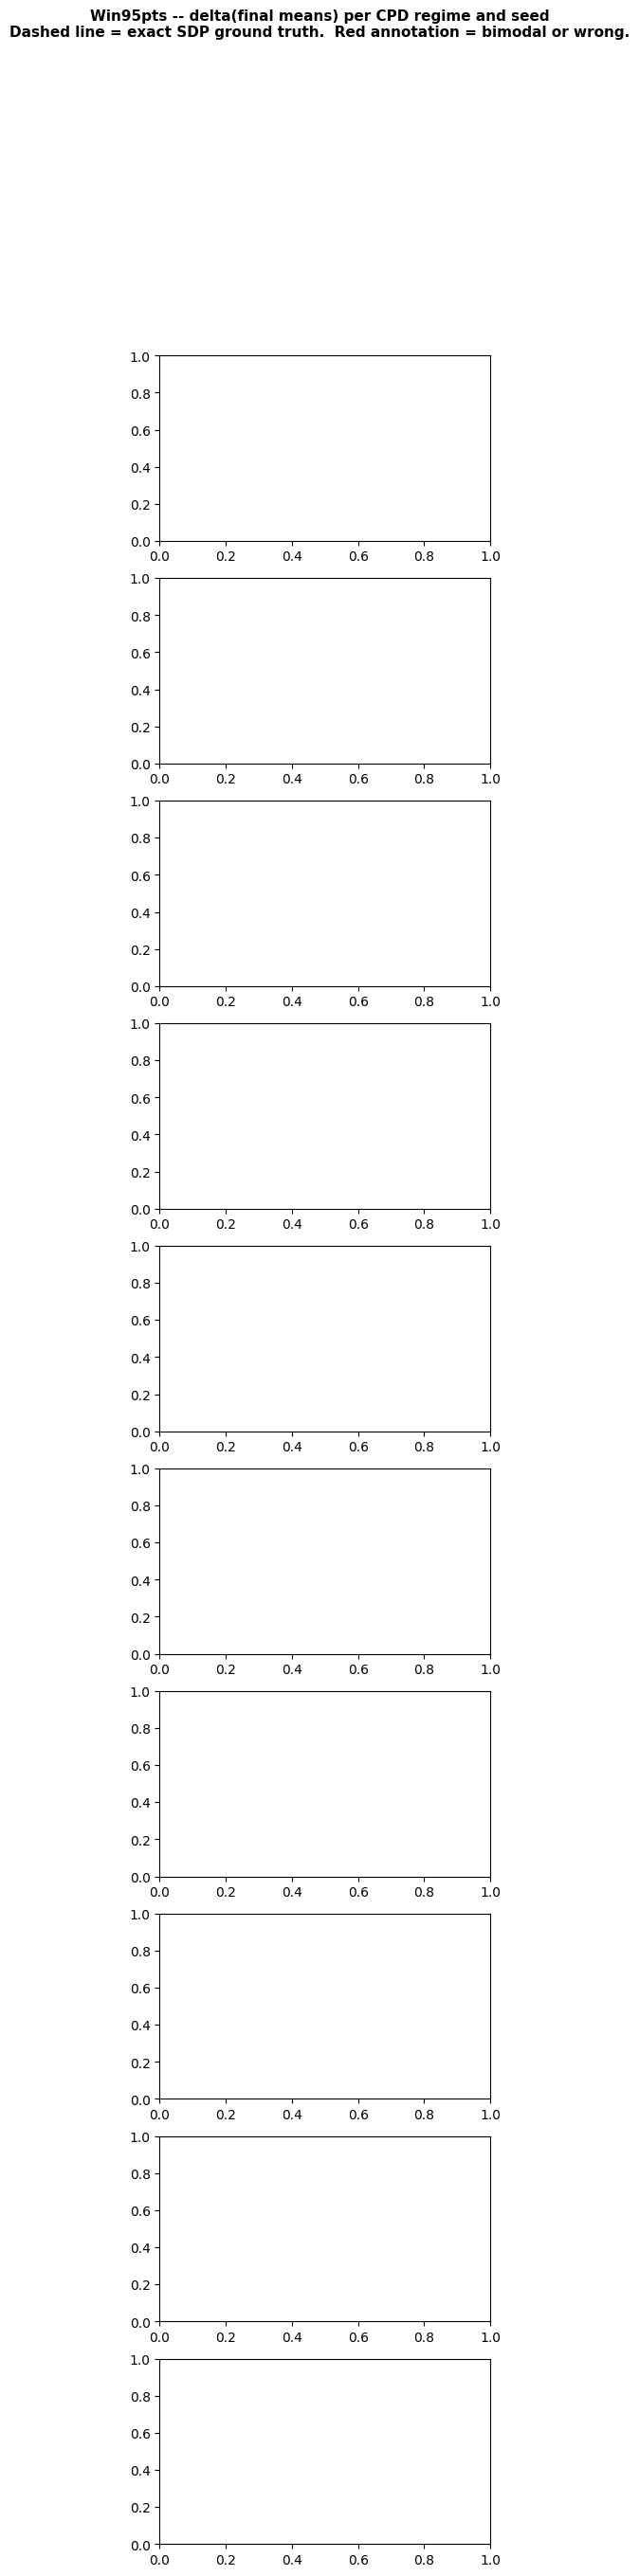

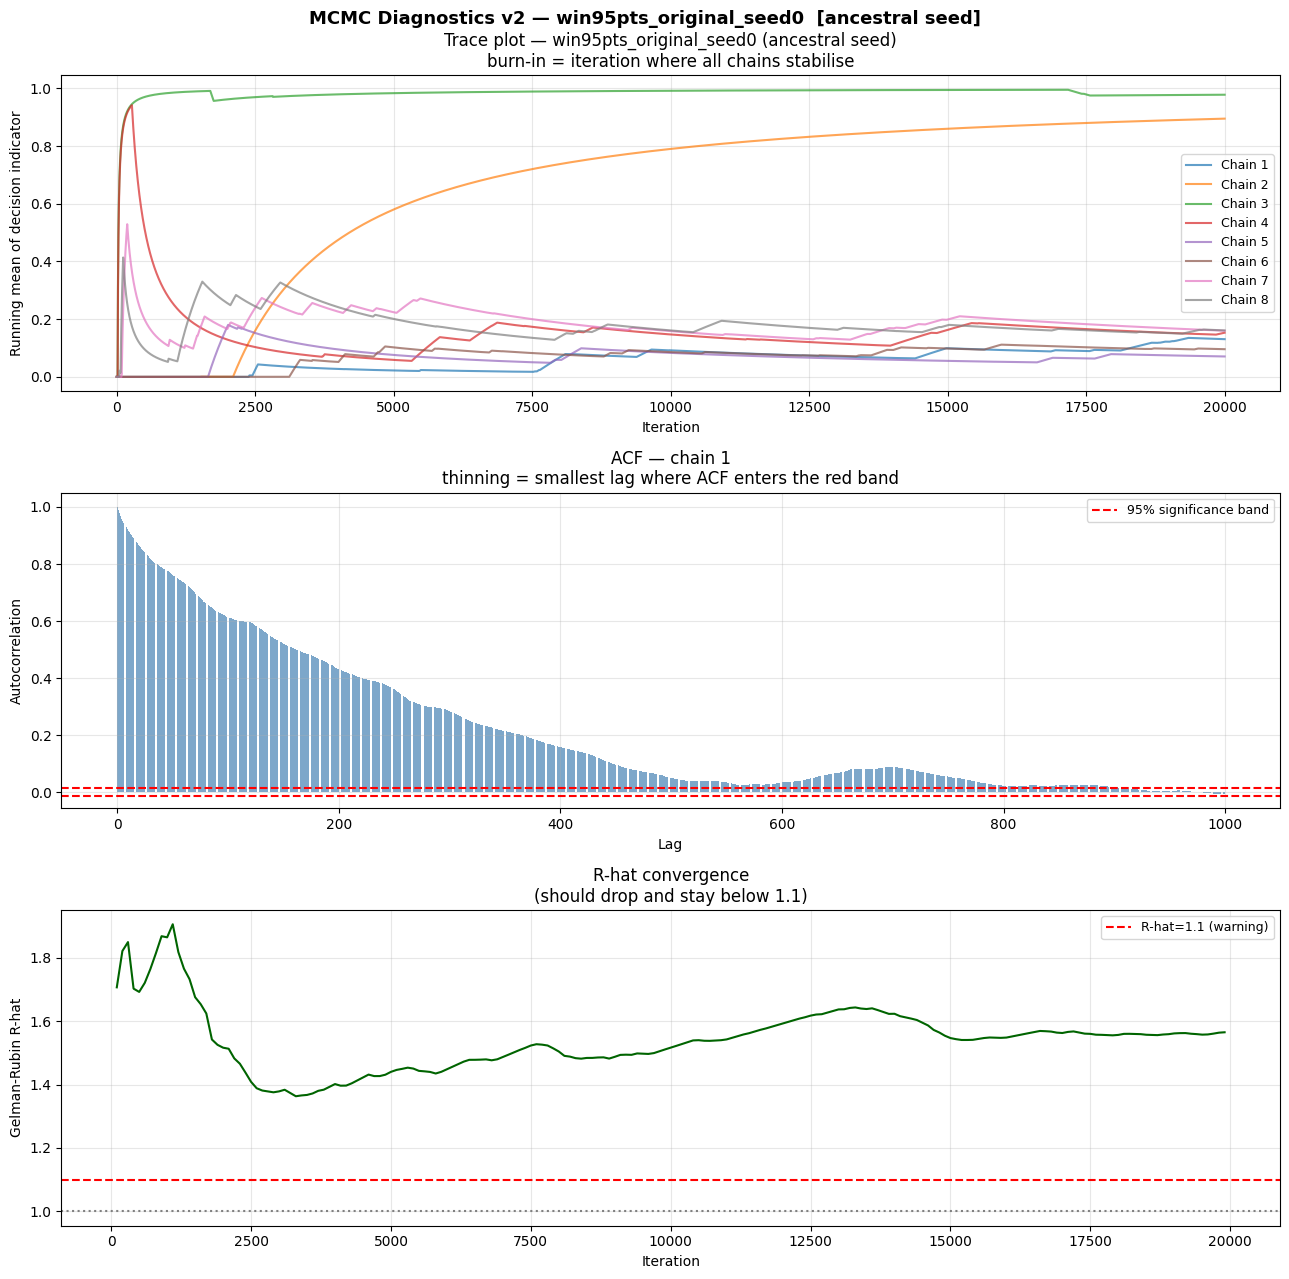


Network      : win95pts_original_seed0
Seed         : ancestral seed
Hidden vars  : 37
Suggested burn-in  : 14673
Suggested thinning : 911
Final R-hat        : 1.5647  ✗ NOT converged

delta=0.907  R=1.565  mean=0.331  err=0.630  [BIMODAL]

Regime 2/10: rigid_extreme
  alpha=0.2, beta=0.2 -- Bimodal: CPDs overwhelmingly near 0 or 1
  Computing exact SDP for regime reference ... exact SDP = 1.0000
  Seed 1/1 ...   Chain 1/8...
CURRENT LOG P 
-106.76468278640438
  Chain 2/8...
CURRENT LOG P 
-112.80650892762374
  Chain 3/8...
CURRENT LOG P 
-105.44128500697254
  Chain 4/8...
CURRENT LOG P 
-119.89377660179473
  Chain 5/8...
CURRENT LOG P 
-113.53040593018058
  Chain 6/8...
CURRENT LOG P 
-104.40545912561969
  Chain 7/8...
CURRENT LOG P 
-118.76906372812937
  Chain 8/8...
CURRENT LOG P 
-104.41370584871144


<ipython-input-32-c6b748d125a0>:219: RuntimeWarning: invalid value encountered in divide
  acf_vals    = acf_raw / acf_raw[0]


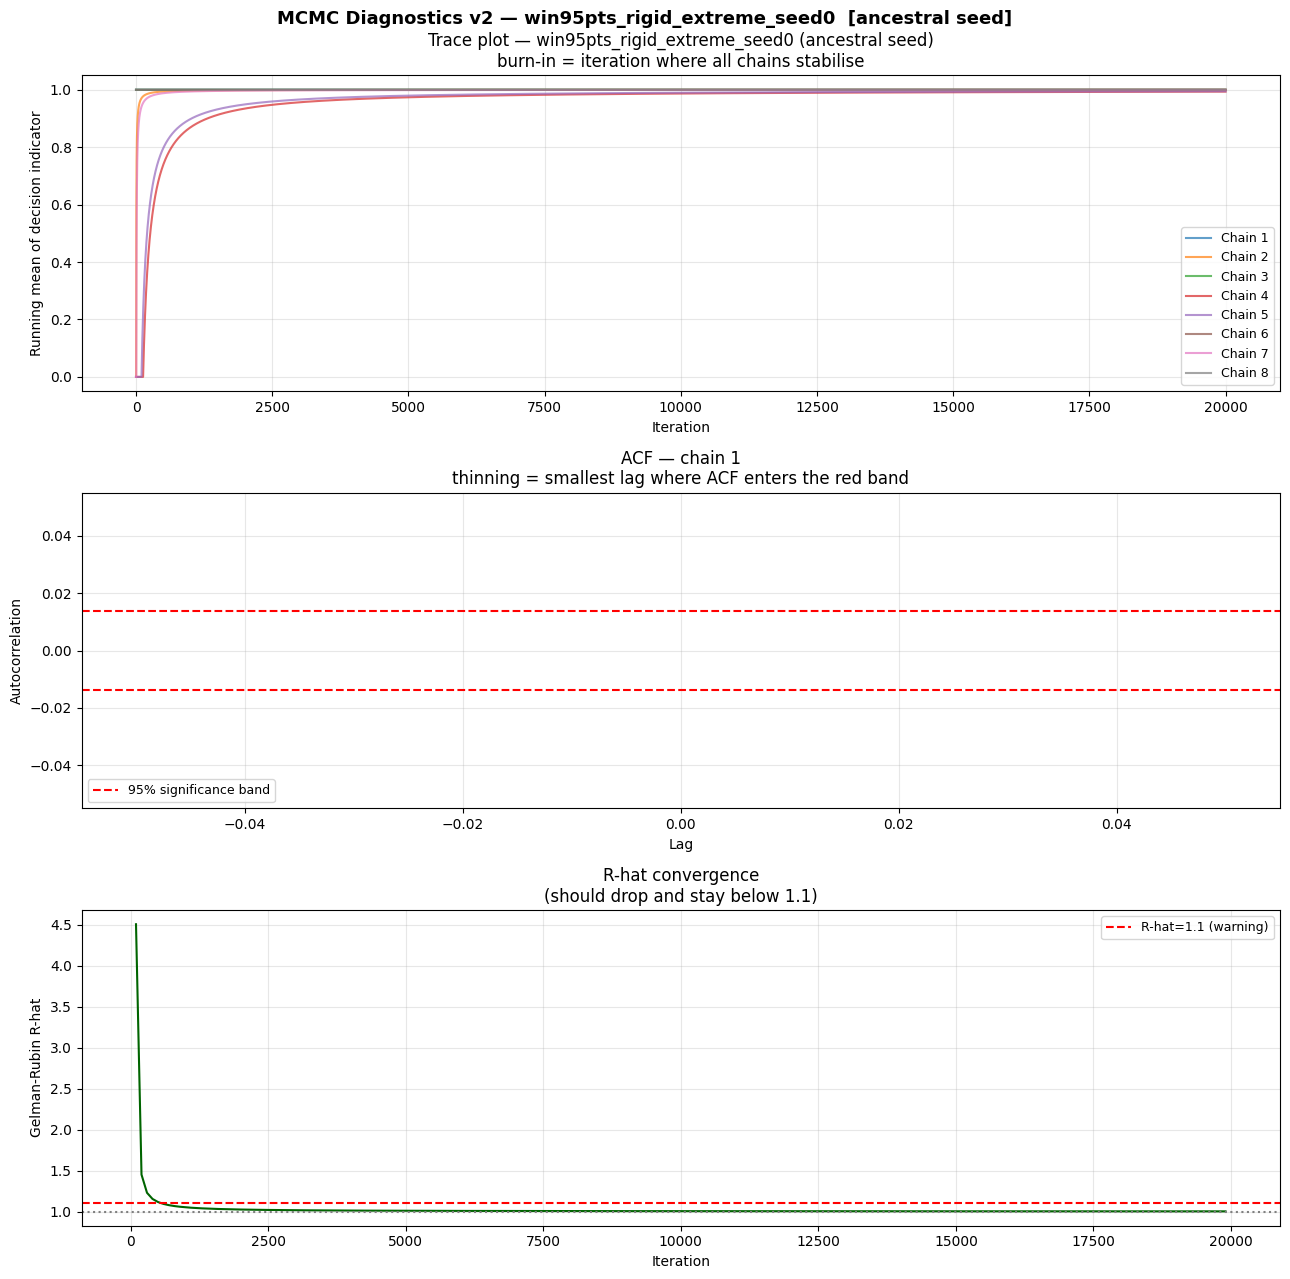


Network      : win95pts_rigid_extreme_seed0
Seed         : ancestral seed
Hidden vars  : 37
Suggested burn-in  : 2316
Suggested thinning : 1000
Final R-hat        : 1.0024  ✓ converged

delta=0.007  R=1.002  mean=0.998  err=0.001  [ok]

Regime 3/10: rigid_moderate
  alpha=0.5, beta=0.5 -- U-shaped: CPDs skewed toward extremes
  Computing exact SDP for regime reference ... exact SDP = 0.8928
  Seed 1/1 ...   Chain 1/8...
CURRENT LOG P 
-42.25530848708691
  Chain 2/8...
CURRENT LOG P 
-40.87548579134975
  Chain 3/8...
CURRENT LOG P 
-43.32981035799263
  Chain 4/8...
CURRENT LOG P 
-49.776685855047205
  Chain 5/8...
CURRENT LOG P 
-38.93265980290687
  Chain 6/8...
CURRENT LOG P 
-41.448194056276385
  Chain 7/8...
CURRENT LOG P 
-46.57104155407337
  Chain 8/8...
CURRENT LOG P 
-47.13513925011025


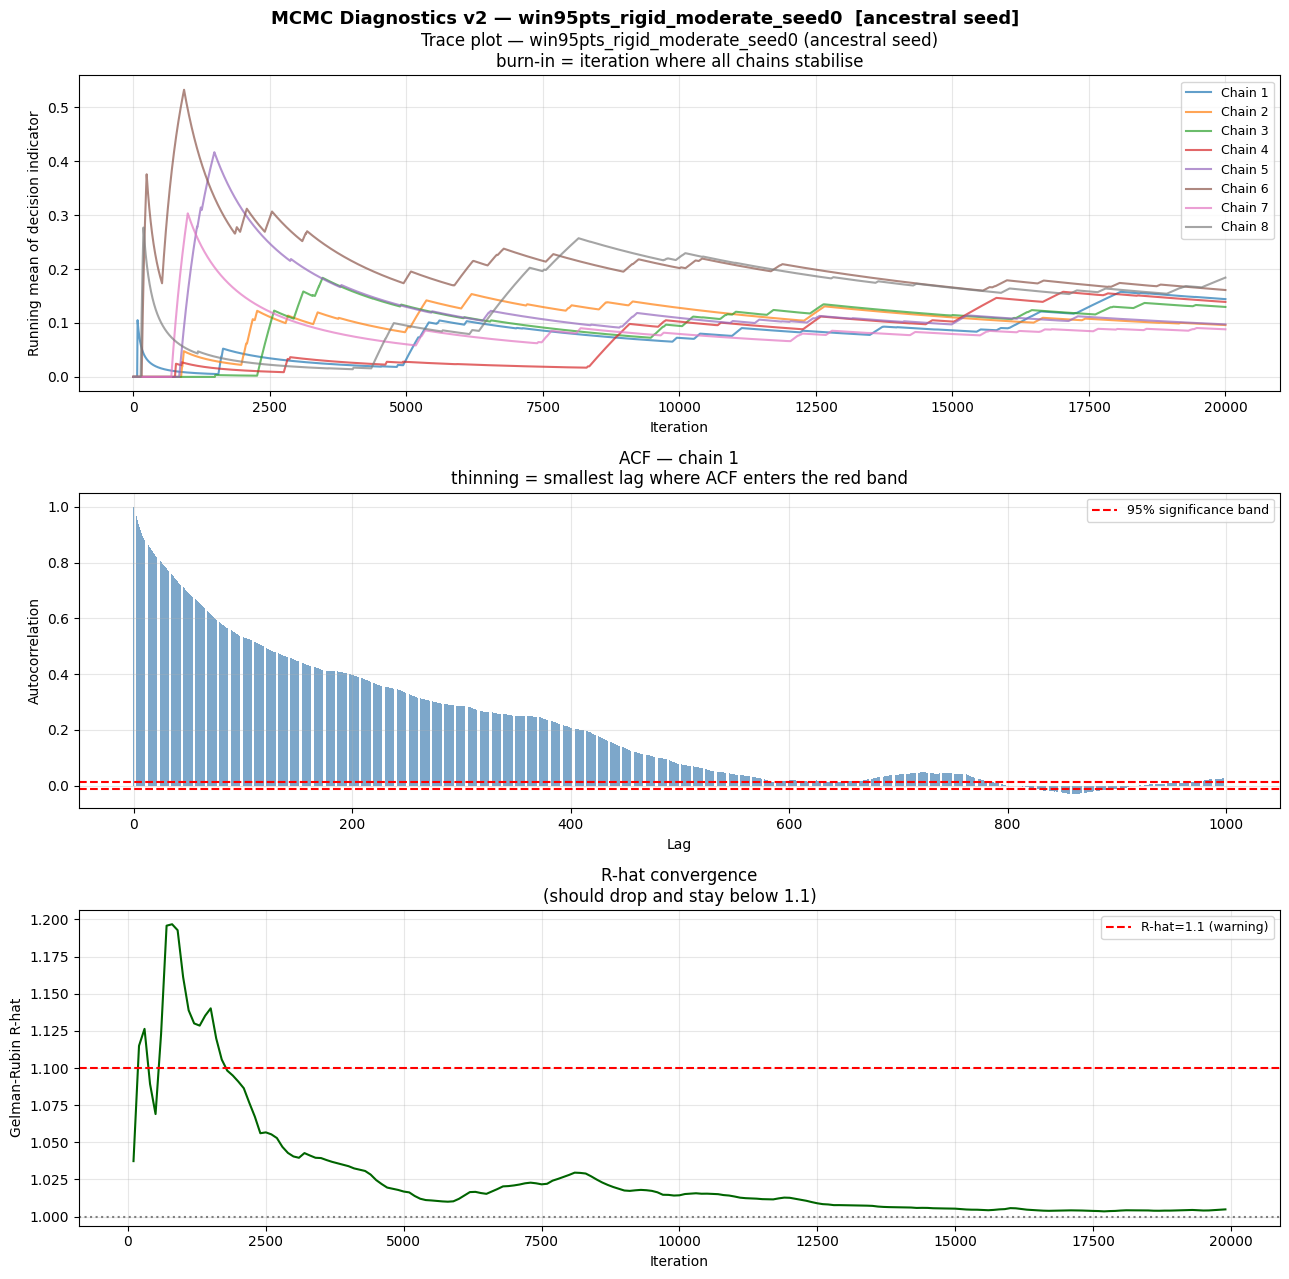


Network      : win95pts_rigid_moderate_seed0
Seed         : ancestral seed
Hidden vars  : 37
Suggested burn-in  : 16104
Suggested thinning : 584
Final R-hat        : 1.0049  ✓ converged

delta=0.096  R=1.005  mean=0.130  err=0.763  [WRONG]

Regime 4/10: uniform
  alpha=1.0, beta=1.0 -- Uniform: all CPD values equally likely
  Computing exact SDP for regime reference ... exact SDP = 0.7955
  Seed 1/1 ...   Chain 1/8...
CURRENT LOG P 
-65.4418619988589
  Chain 2/8...
CURRENT LOG P 
-65.4929715266291
  Chain 3/8...
CURRENT LOG P 
-66.00741839326581
  Chain 4/8...
CURRENT LOG P 
-71.79657754357999
  Chain 5/8...
CURRENT LOG P 
-56.46635956132109
  Chain 6/8...
CURRENT LOG P 
-69.61677982974655
  Chain 7/8...
CURRENT LOG P 
-64.09169247136248
  Chain 8/8...
CURRENT LOG P 
-63.886703185701364


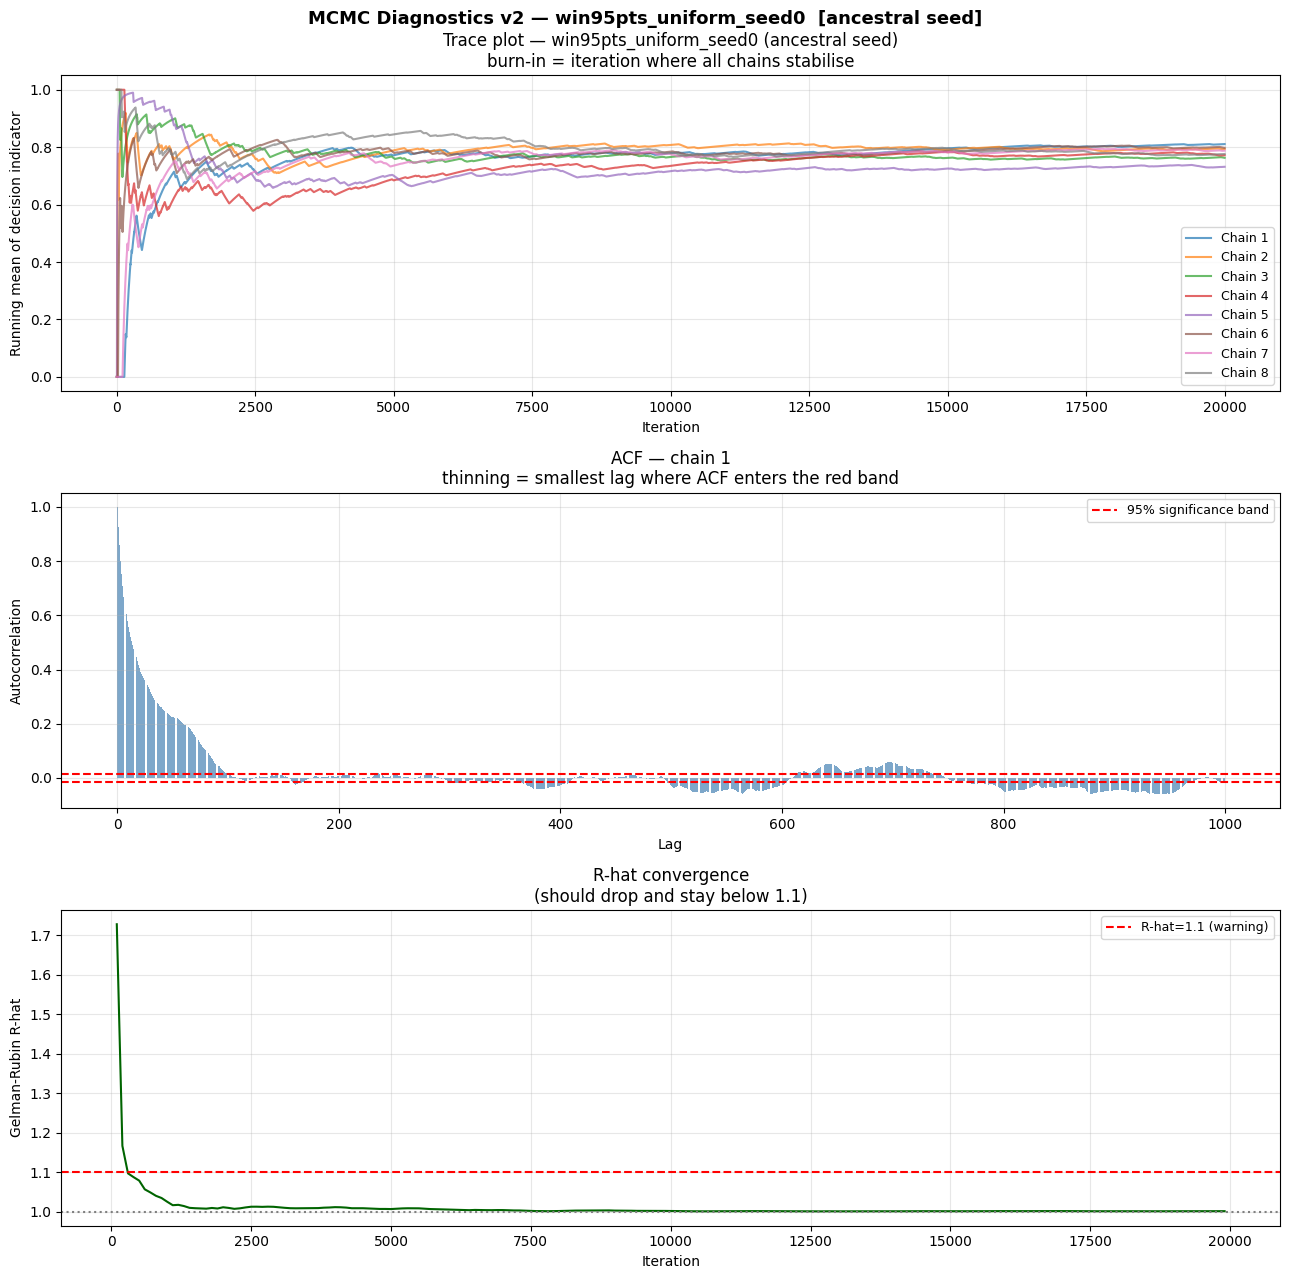


Network      : win95pts_uniform_seed0
Seed         : ancestral seed
Hidden vars  : 37
Suggested burn-in  : 7101
Suggested thinning : 101
Final R-hat        : 1.0018  ✓ converged

delta=0.079  R=1.002  mean=0.779  err=0.016  [ok]

Regime 5/10: uncertain_moderate
  alpha=3.0, beta=3.0 -- Bell-shaped: CPDs concentrated near 0.5
  Computing exact SDP for regime reference ... exact SDP = 0.8619
  Seed 1/1 ...   Chain 1/8...
CURRENT LOG P 
-49.85934342869028
  Chain 2/8...
CURRENT LOG P 
-48.81898241380308
  Chain 3/8...
CURRENT LOG P 
-50.66294615782283
  Chain 4/8...
CURRENT LOG P 
-49.16341506530653
  Chain 5/8...
CURRENT LOG P 
-51.400093339457335
  Chain 6/8...
CURRENT LOG P 
-47.2563132134272
  Chain 7/8...
CURRENT LOG P 
-47.93758884849776
  Chain 8/8...
CURRENT LOG P 
-49.688969627501244


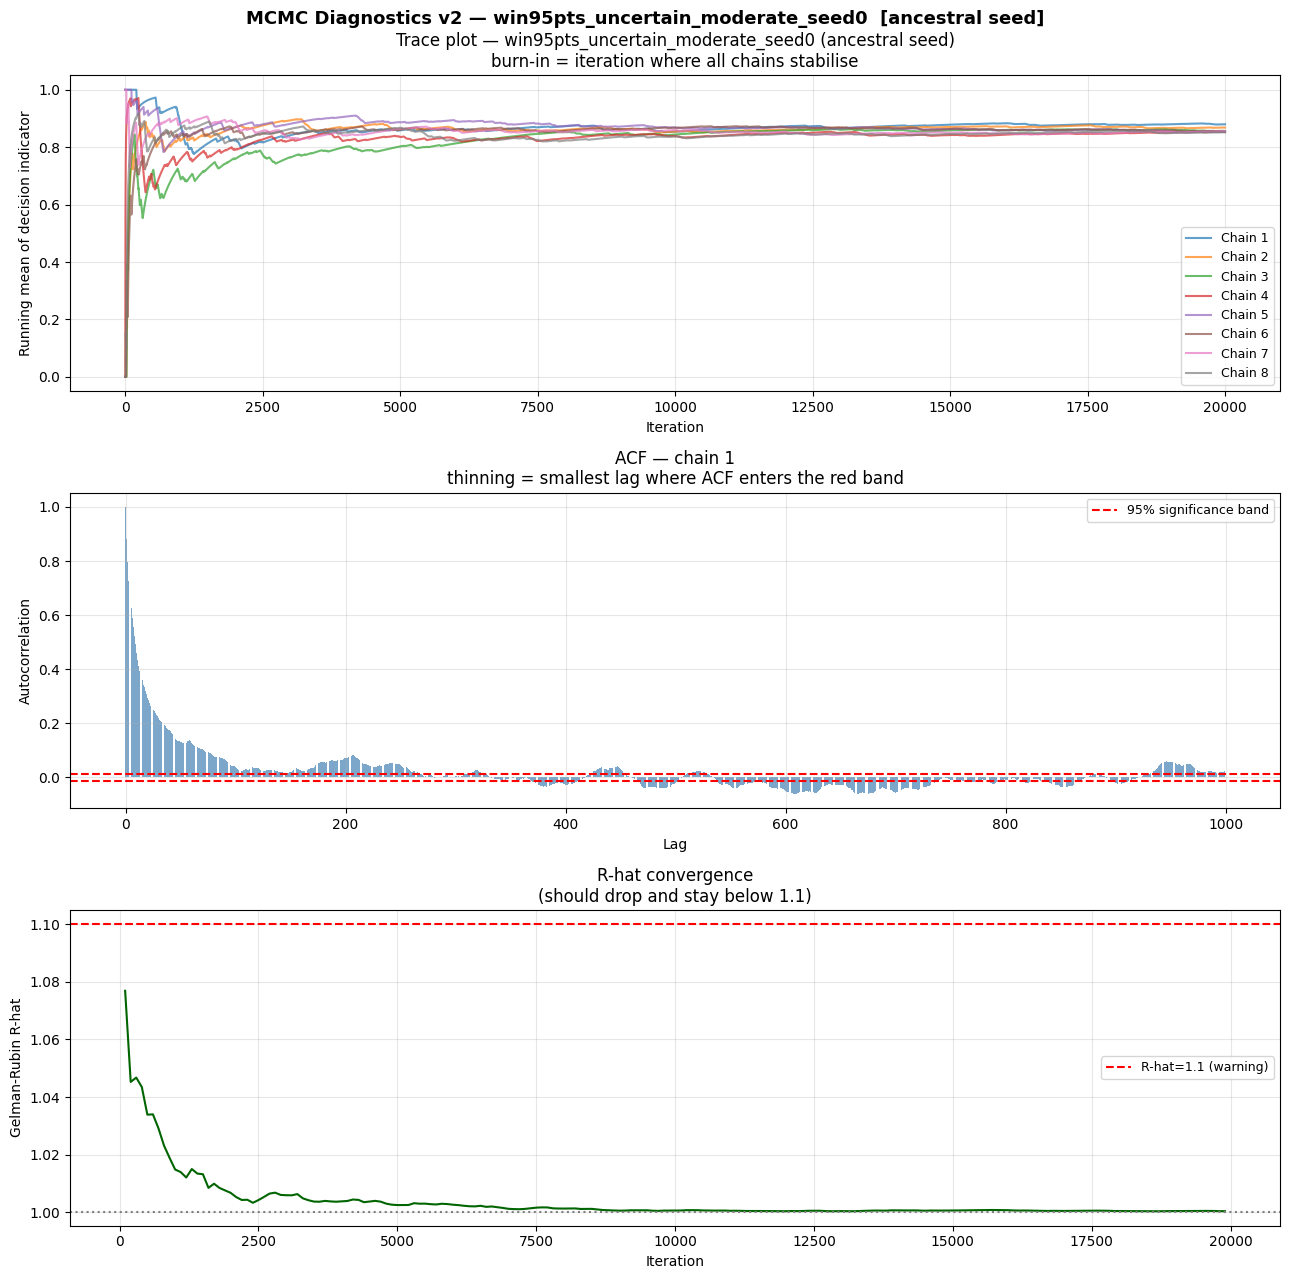


Network      : win95pts_uncertain_moderate_seed0
Seed         : ancestral seed
Hidden vars  : 37
Suggested burn-in  : 5154
Suggested thinning : 267
Final R-hat        : 1.0003  ✓ converged

delta=0.028  R=1.000  mean=0.859  err=0.003  [ok]

Regime 6/10: uncertain_strong
  alpha=10.0, beta=10.0 -- Tightly concentrated near 0.5
  Computing exact SDP for regime reference ... exact SDP = 0.8291
  Seed 1/1 ...   Chain 1/8...
CURRENT LOG P 
-52.19922334108256
  Chain 2/8...
CURRENT LOG P 
-54.425959930496546
  Chain 3/8...
CURRENT LOG P 
-52.44667837850478
  Chain 4/8...
CURRENT LOG P 
-52.38412042281482
  Chain 5/8...
CURRENT LOG P 
-53.55395176835252
  Chain 6/8...
CURRENT LOG P 
-52.42345823633346
  Chain 7/8...
CURRENT LOG P 
-51.362224756106706
  Chain 8/8...
CURRENT LOG P 
-53.273176226508305


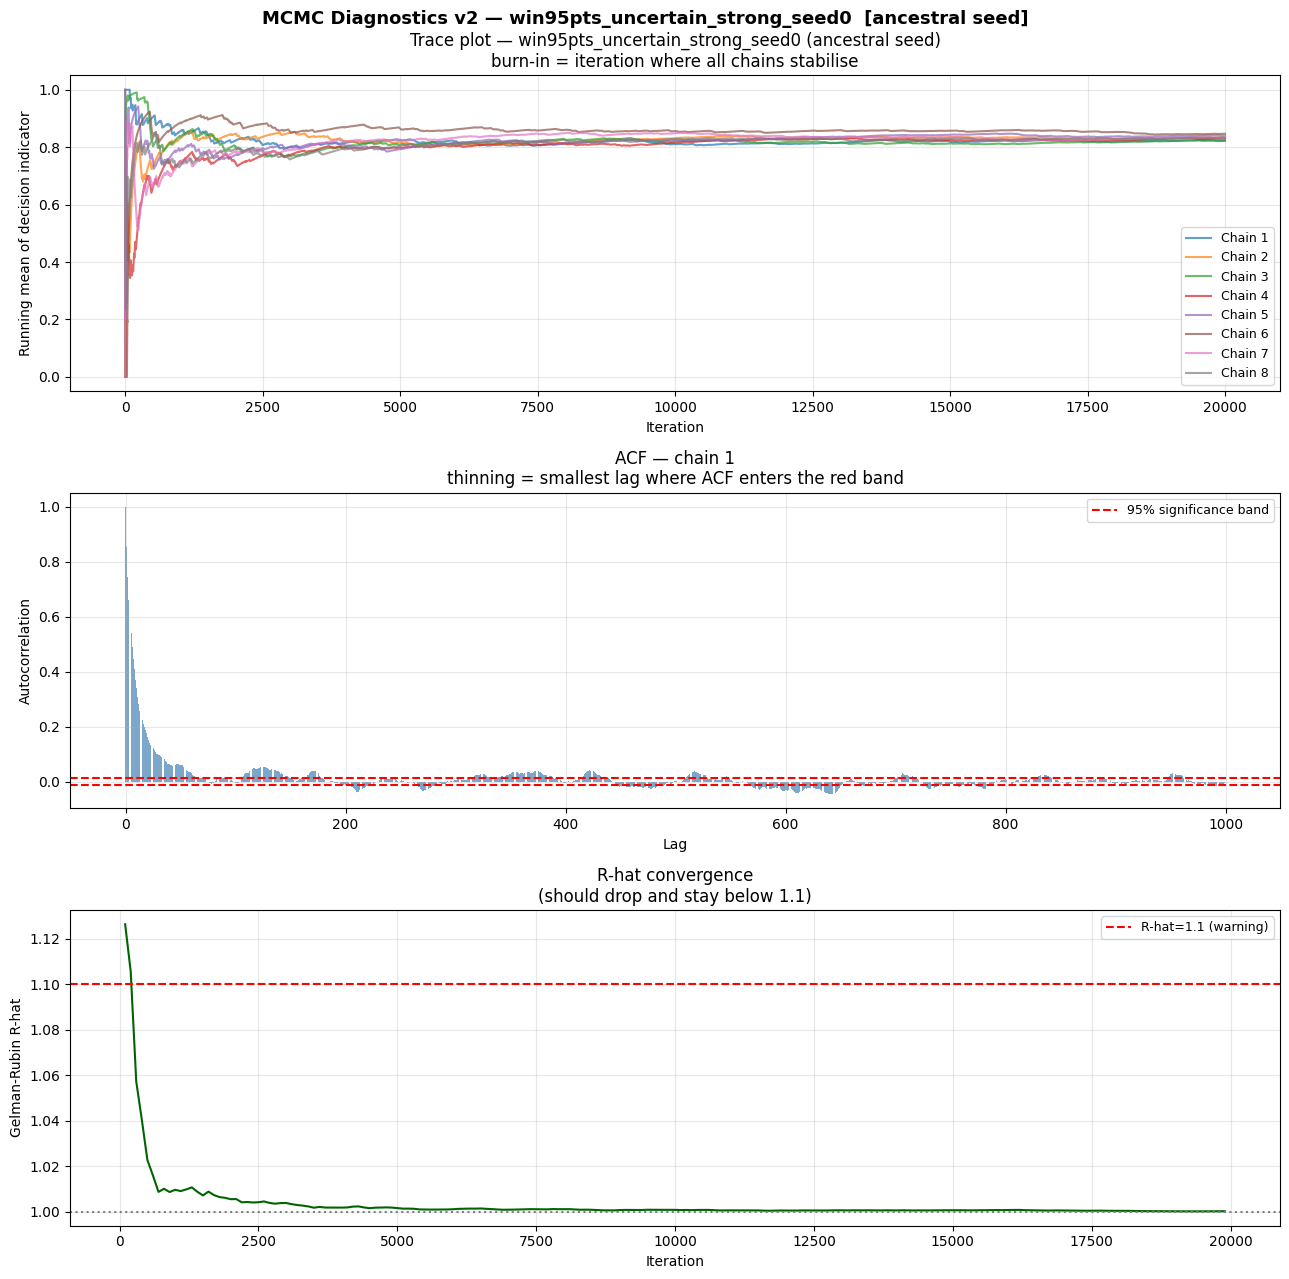


Network      : win95pts_uncertain_strong_seed0
Seed         : ancestral seed
Hidden vars  : 37
Suggested burn-in  : 3461
Suggested thinning : 66
Final R-hat        : 1.0002  ✓ converged

delta=0.024  R=1.000  mean=0.832  err=0.003  [ok]

Regime 7/10: spread_bias_low
  alpha=0.5, beta=2.0 -- Spread + biased low: mean(p) ≈ 0.20, some variance
  Computing exact SDP for regime reference ... exact SDP = 0.9973
  Seed 1/1 ...   Chain 1/8...
CURRENT LOG P 
-46.49028281192487
  Chain 2/8...
CURRENT LOG P 
-54.56871864811427
  Chain 3/8...
CURRENT LOG P 
-51.84370873443562
  Chain 4/8...
CURRENT LOG P 
-47.587854114111025
  Chain 5/8...
CURRENT LOG P 
-52.43553811785309
  Chain 6/8...
CURRENT LOG P 
-46.41146710435213
  Chain 7/8...
CURRENT LOG P 
-48.62148735241348
  Chain 8/8...
CURRENT LOG P 
-51.94993108116916


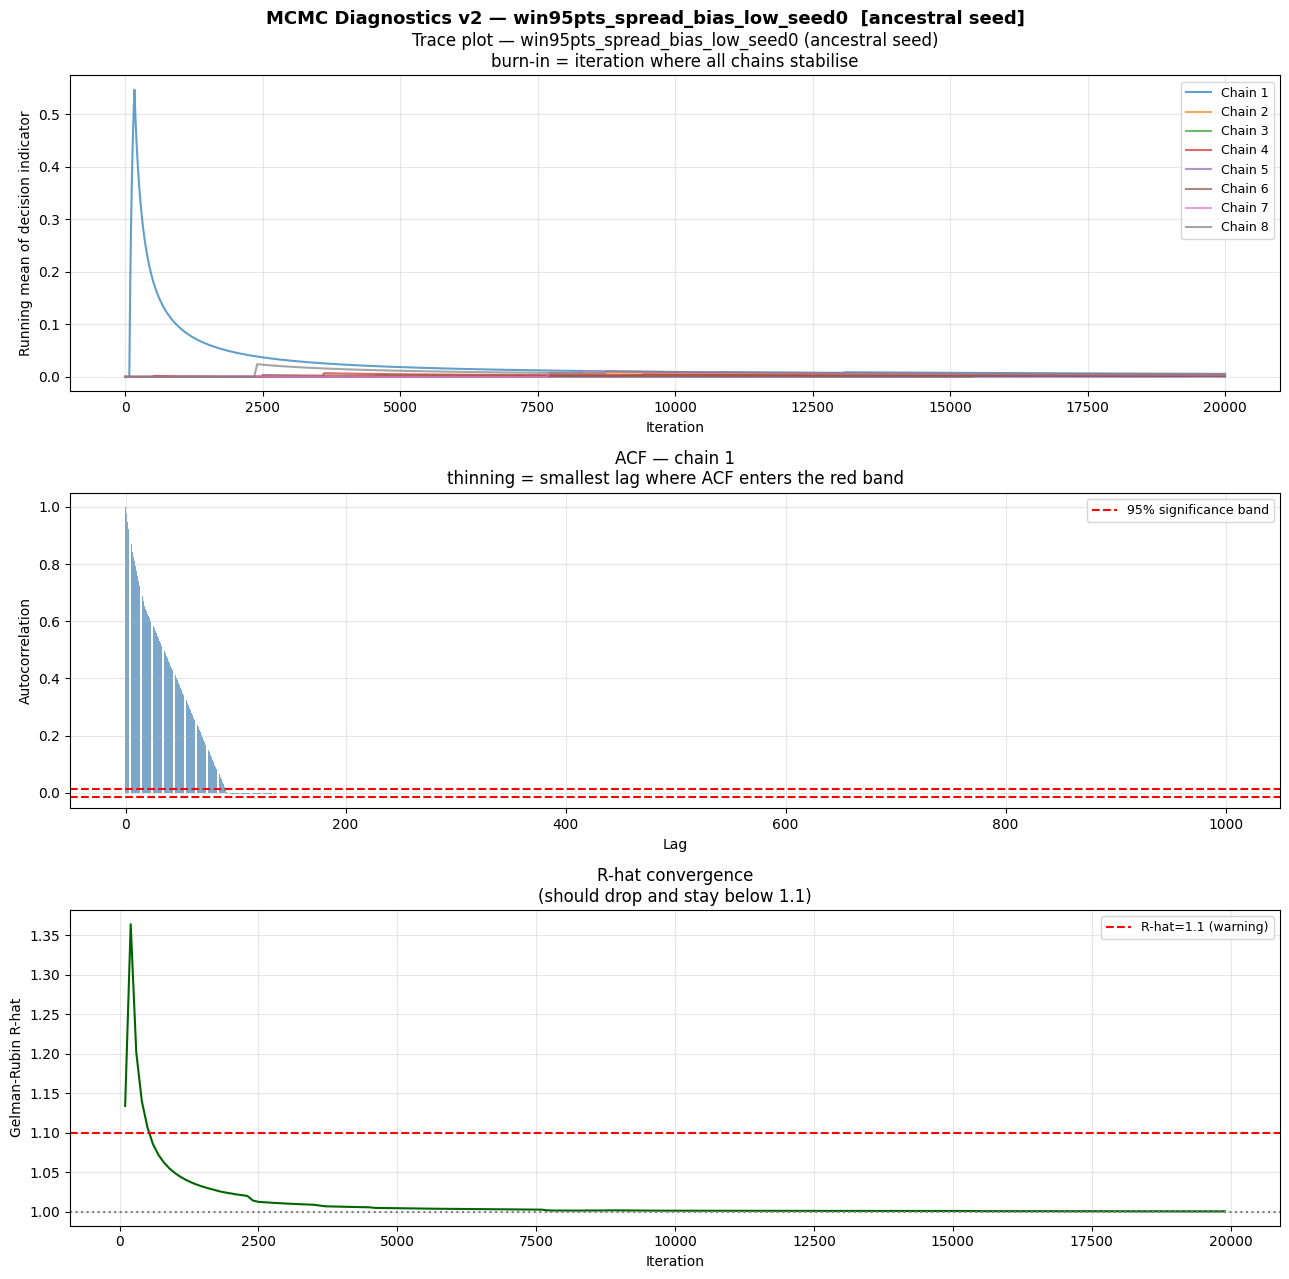


Network      : win95pts_spread_bias_low_seed0
Seed         : ancestral seed
Hidden vars  : 37
Suggested burn-in  : 0
Suggested thinning : 91
Final R-hat        : 1.0005  ✓ converged

delta=0.005  R=1.001  mean=0.003  err=0.994  [WRONG]

Regime 8/10: concentrated_bias_low
  alpha=1.0, beta=5.0 -- Concentrated near 0: mean(p) ≈ 0.17, low variance
  Computing exact SDP for regime reference ... exact SDP = 0.9381
  Seed 1/1 ...   Chain 1/8...
CURRENT LOG P 
-43.82244664709997
  Chain 2/8...
CURRENT LOG P 
-47.52307894682893
  Chain 3/8...
CURRENT LOG P 
-43.49406229920575
  Chain 4/8...
CURRENT LOG P 
-42.79880939636007
  Chain 5/8...
CURRENT LOG P 
-43.696777953554395
  Chain 6/8...
CURRENT LOG P 
-46.43488111250847
  Chain 7/8...
CURRENT LOG P 
-40.82359567007979
  Chain 8/8...
CURRENT LOG P 
-46.05301791257523


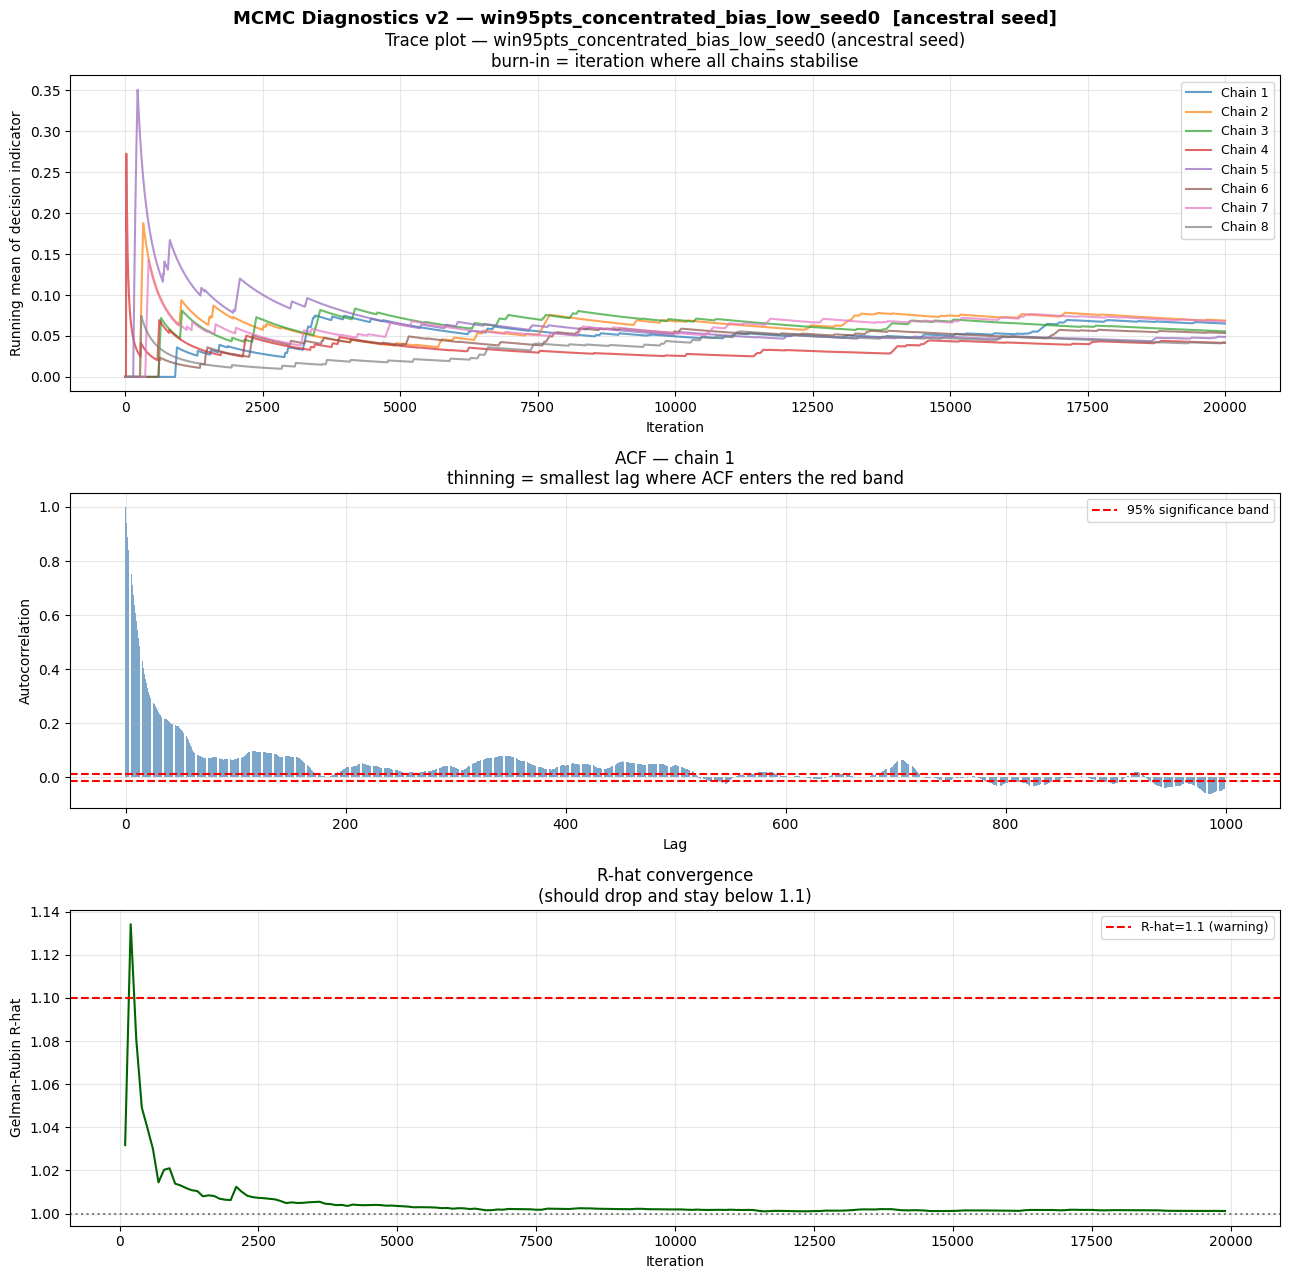


Network      : win95pts_concentrated_bias_low_seed0
Seed         : ancestral seed
Hidden vars  : 37
Suggested burn-in  : 1557
Suggested thinning : 173
Final R-hat        : 1.0012  ✓ converged

delta=0.027  R=1.001  mean=0.055  err=0.883  [WRONG]

Regime 9/10: spread_bias_high
  alpha=2.0, beta=0.5 -- Spread + biased high: mean(p) ≈ 0.80, some variance
  Computing exact SDP for regime reference ... exact SDP = 0.9964
  Seed 1/1 ...   Chain 1/8...
CURRENT LOG P 
-90.03868780115346
  Chain 2/8...
CURRENT LOG P 
-93.90767865022275
  Chain 3/8...
CURRENT LOG P 
-95.75282098874965
  Chain 4/8...
CURRENT LOG P 
-115.80144225267291
  Chain 5/8...
CURRENT LOG P 
-91.40304275534953
  Chain 6/8...
CURRENT LOG P 
-86.68721499271862
  Chain 7/8...
CURRENT LOG P 
-90.57551065839726
  Chain 8/8...
CURRENT LOG P 
-90.042070031897


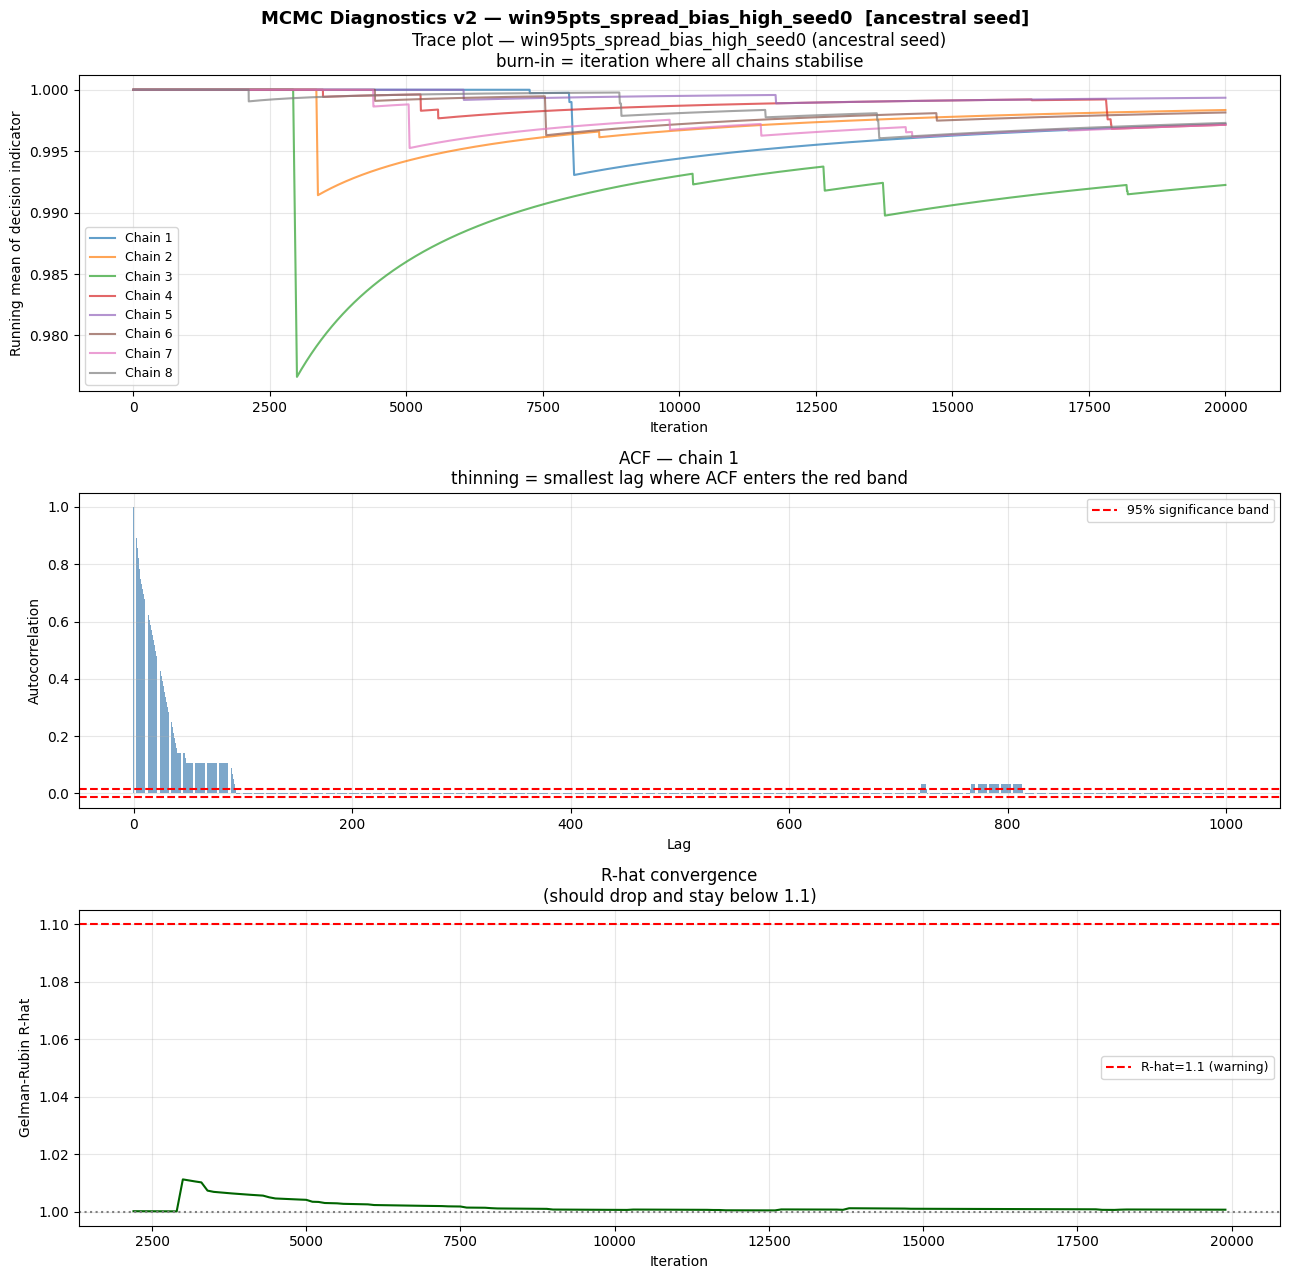


Network      : win95pts_spread_bias_high_seed0
Seed         : ancestral seed
Hidden vars  : 37
Suggested burn-in  : 0
Suggested thinning : 94
Final R-hat        : 1.0008  ✓ converged

delta=0.007  R=1.001  mean=0.997  err=0.001  [ok]

Regime 10/10: concentrated_bias_high
  alpha=5.0, beta=1.0 -- Concentrated near 1: mean(p) ≈ 0.83, low variance
  Computing exact SDP for regime reference ... exact SDP = 0.6924
  Seed 1/1 ...   Chain 1/8...
CURRENT LOG P 
-65.53602282533163
  Chain 2/8...
CURRENT LOG P 
-66.05785714420708
  Chain 3/8...
CURRENT LOG P 
-65.76771249928895
  Chain 4/8...
CURRENT LOG P 
-73.81564865130896
  Chain 5/8...
CURRENT LOG P 
-71.38918741089019
  Chain 6/8...
CURRENT LOG P 
-67.37318522912766
  Chain 7/8...
CURRENT LOG P 
-66.23481640446266
  Chain 8/8...
CURRENT LOG P 
-60.72061463257305


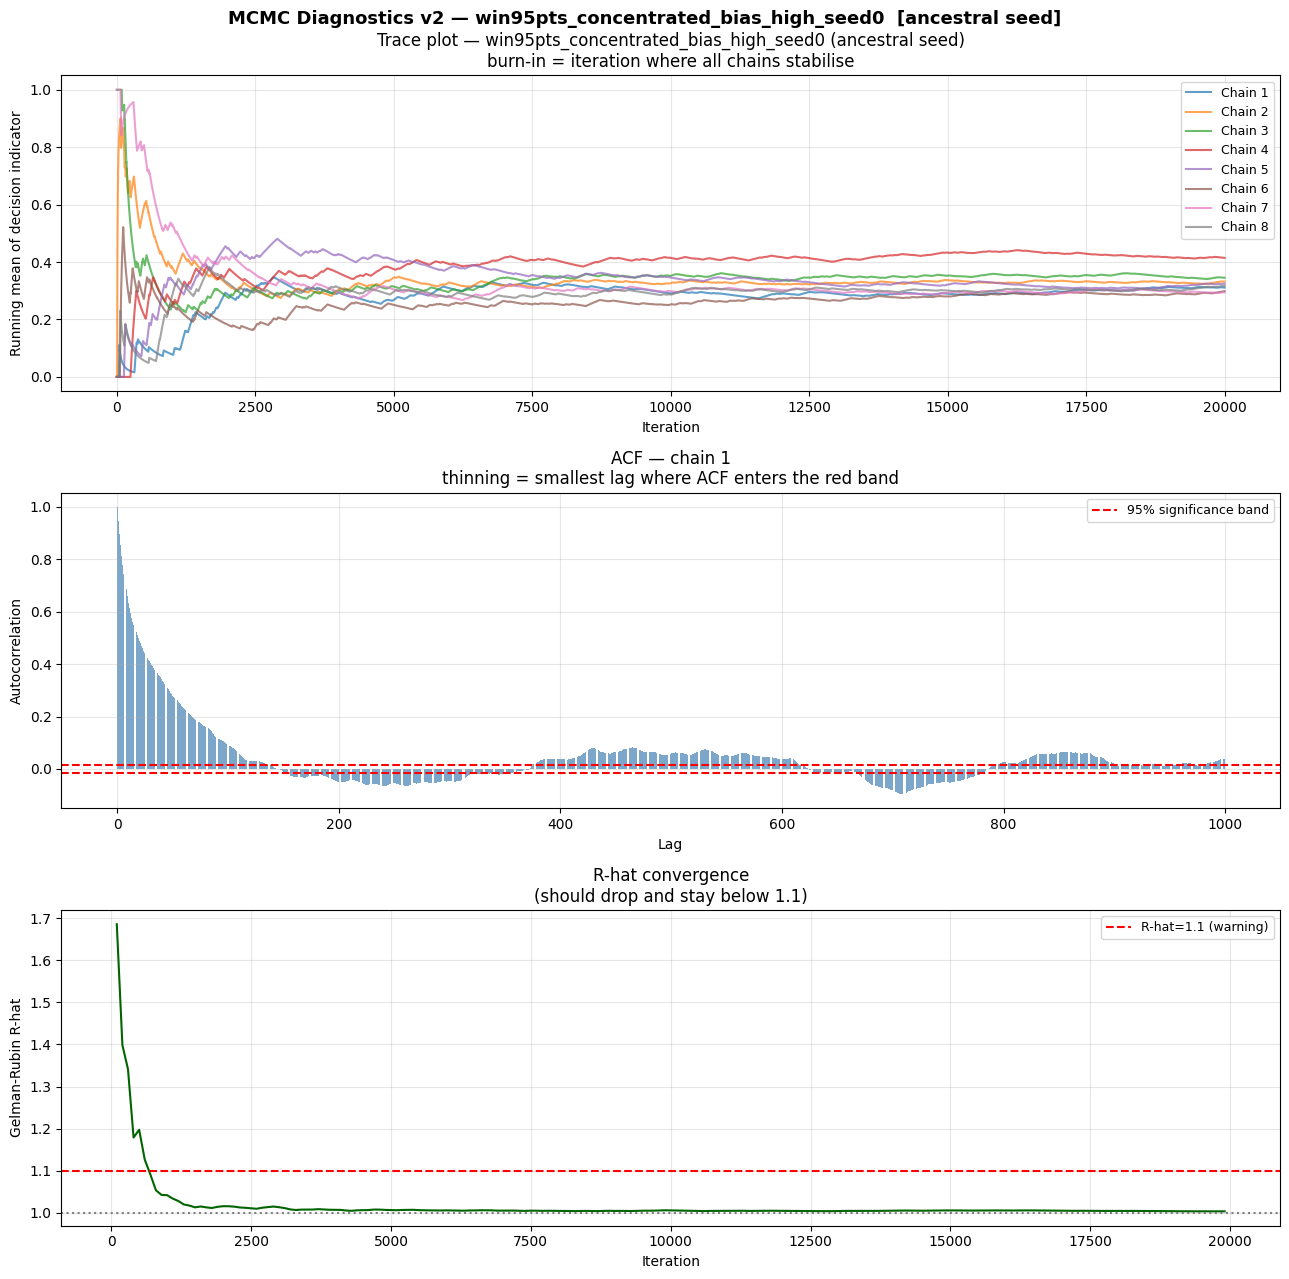


Network      : win95pts_concentrated_bias_high_seed0
Seed         : ancestral seed
Hidden vars  : 37
Suggested burn-in  : 5790
Suggested thinning : 139
Final R-hat        : 1.0035  ✓ converged

delta=0.120  R=1.004  mean=0.330  err=0.363  [BIMODAL]

Summary grid saved -> cpt_bimodality_results/summary_grid.png
Results CSV saved -> cpt_bimodality_results/cpt_bimodality_results.csv

SUMMARY -- per regime (mean over seeds)
Regime                        a    b   exact   mean_d   mean_err   bimodal%   wrong%
---------------------------------------------------------------------------
  original                  0.0  0.0   0.961    0.907      0.630       100%       0%
  rigid_extreme             0.2  0.2   1.000    0.007      0.001         0%       0%
  rigid_moderate            0.5  0.5   0.893    0.096      0.763         0%     100%
  uniform                   1.0  1.0   0.795    0.079      0.016         0%       0%
  uncertain_moderate        3.0  3.0   0.862    0.028      0.003         0

In [34]:
win95pts_model = get_example_model('win95pts')
target         = select_optimal_target_node(win95pts_model)
target_states  = win95pts_model.get_cpds(target).state_names[target]
target_value   = target_states[1]

interesting_patient = {
    'TTOK': 'No', 'NtSpd': 'OK', 'PgOrnttnOK': 'Incorrect', 'NetOK': 'Yes',
    'TrTypFnts': 'No', 'PrtPath': 'Correct', 'PrtPaper': 'No_Paper',
    'Problem1': 'No_Output', 'AppData': 'Correct', 'PrtDataOut': 'Yes',
    'PSERRMEM': 'Low_Memory', 'Problem4': 'Yes', 'FntInstlltn': 'Verified',
    'NnTTOK': 'No', 'AppDtGnTm': 'Fast_Enough',
    'DskLocal': 'Greater_than_2_Mb', 'PrtSel': 'Yes', 'Problem5': 'No',
    'IncmpltPS': 'Yes', 'PrtIcon': 'Normal', 'GDIIN': 'Yes',
    'PrtData': 'Yes', 'PrtPScript': 'Yes',
    'HrglssDrtnAftrPrnt': 'Fast_Enough', 'AvlblVrtlMmry': 'Adequate____1Mb_',
    'PrtPort': 'Yes', 'GrbldOtpt': 'No', 'GDIOUT': 'Yes',
    'TnrSpply': 'Adequate', 'PrntrAccptsTrtyp': 'No', 'PrtOn': 'No',
    'Problem6': 'No', 'PrtSpool': 'Disabled',
    'TstpsTxt': 'x_1_Mb_Available_VM', 'PrtTimeOut': 'Long_Enough',
    'PrntPrcssTm': 'Too_Long', 'PrtStatToner': 'Low__None', 'DrvSet': 'Correct',
}

# Add original CPDs as regime 0 for baseline comparison
CPD_PARAMS_WITH_ORIGINAL = [
    CPDParam(0.0, 0.0, 'original', 'Original Win95pts CPDs (unchanged)'),
] + CPD_PARAMS

# Temporarily patch CPD_PARAMS so the experiment loop uses the extended list
import builtins
_orig = CPD_PARAMS[:]
CPD_PARAMS.clear()
CPD_PARAMS.extend(CPD_PARAMS_WITH_ORIGINAL)

df = run_cpt_bimodality_experiment(
    interesting_patient=interesting_patient,
    target=target,
    target_value=target_value,
    threshold=0.5,
    n_iterations=20_000,
    n_chains=8,
    n_seeds=1,
    output_dir="cpt_bimodality_results",
    use_lw_seed=True,
)

CPD_PARAMS.clear()
CPD_PARAMS.extend(_orig)

In [35]:
cpd = win95pts_model.get_cpds('PrtOn')
print(type(cpd.state_names), cpd.state_names)

<class 'dict'> {'PrtOn': ['Yes', 'No']}
